<a href="https://colab.research.google.com/github/shreya21-cloud/iitDelhi_project/blob/main/practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading VQA model... Please wait


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model loaded successfully!

Upload an image


Saving gettyimages-1634186550-612x612.jpg to gettyimages-1634186550-612x612 (2).jpg


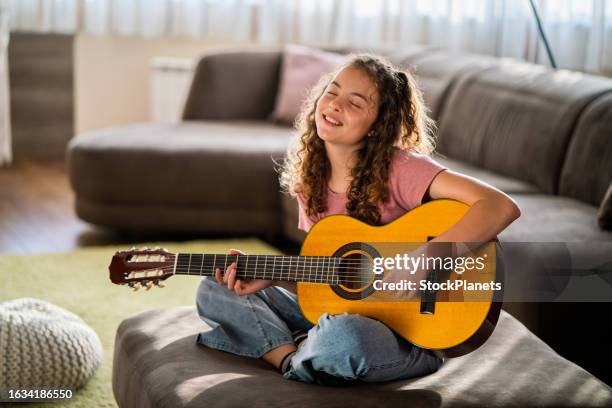


Ask questions about the image
Type 'change' to upload a new image
Type 'exit' to stop the program

Your Question: what is this image


[transformers] The input data was not formatted as a chat with dicts containing 'role' and 'content' keys, even though this model supports chat. Consider using the chat format for better results. For more information, see https://huggingface.co/docs/transformers/en/chat_templating
[transformers] Keyword argument `do_sample` is not a valid argument for this processor and will be ignored.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: Futu


Answer:
The image features a young girl sitting on a couch, holding a guitar in her hands. She appears to be playing the guitar, possibly practicing or enjoying a musical moment. The couch is positioned in the background, and the girl seems to be the main focus of the scene.

Your Question: describe this image in short


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Answer:
A young girl is sitting on a couch, holding a guitar and smiling. She appears to be enjoying her time playing the guitar. The room she is in has a comfortable and inviting atmosphere.

Your Question: is something unusual about this image?


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Answer:
Yes, there is something unusual about this image. The young girl is sitting on a couch and playing a guitar, but she is also smiling and looking up, which is not a typical pose for a musician. It is more common for musicians to be focused on their instruments or the

Your Question: change

Upload an image


Saving images.jpg to images.jpg


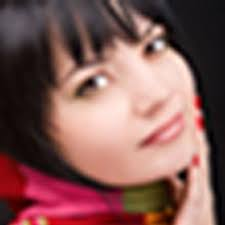


Your Question: what is this image?


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Answer:
The image features a woman with dark hair, wearing a pink scarf, and smiling at the camera. She is posing for a picture, possibly in front of a black background. The woman appears to be the main focus of the image, and her smile adds a warm and friendly

Your Question: is this low resolution or high resolution image?


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Answer:
This is a high resolution image of a woman.

Your Question: i think this is low resolution image


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Answer:
Yes, the image appears to be of low resolution, which might affect the clarity and details of the woman's face and surroundings.

Your Question: then why are you saying high resolution image


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Answer:
I apologize for the confusion. The image is indeed a high resolution photo of a woman's face. The woman in the image is smiling and has a pink scarf around her neck. The image is clear and detailed, allowing for a close-up view of her facial features

Your Question: change

Upload an image


Saving gettyimages-598167278-612x612.jpg to gettyimages-598167278-612x612 (3).jpg


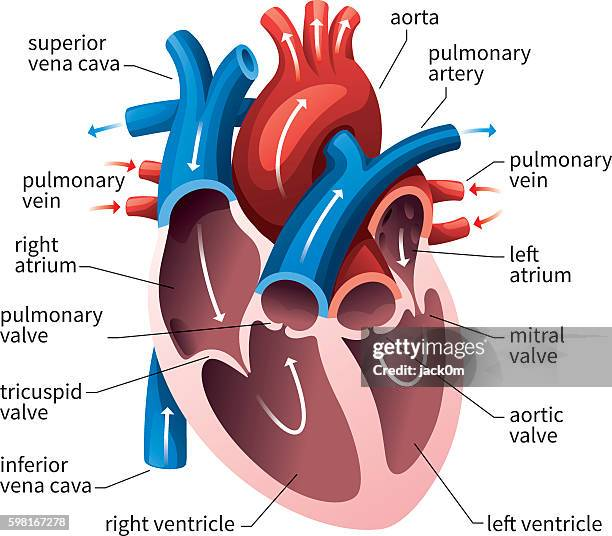


Your Question: tell this image in 10 words


[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Answer:
A diagram of the human heart.


In [ ]:
!pip install -q transformers accelerate bitsandbytes pillow

import torch
from transformers import pipeline, BitsAndBytesConfig
from PIL import Image
from google.colab import files

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

try:
    print("Loading VQA model... Please wait")

    pipe = pipeline(
        "image-text-to-text",
        model="llava-hf/llava-1.5-7b-hf",
        device_map="auto",
        model_kwargs={
            "quantization_config": bnb_config,
            "low_cpu_mem_usage": True
        }
    )

    print("Model loaded successfully!")

except Exception as e:
    print("Error while loading model:")
    print(e)
    raise SystemExit


def upload_image():
    print("\nUpload an image")
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise ValueError("No image uploaded.")

    image_path = list(uploaded.keys())[0]
    img = Image.open(image_path).convert("RGB")
    display(img)
    return img


try:
    image = upload_image()

except Exception as e:
    print("Error while uploading/opening image:")
    print(e)
    raise SystemExit


print("\nAsk questions about the image")
print("Type 'change' to upload a new image")
print("Type 'exit' to stop the program")

while True:

    try:
        command = input("\nYour Question: ").strip()

        if command.lower() == "exit":
            print("Program stopped.")
            break

        if command.lower() == "change":
            image = upload_image()
            continue

        if command == "":
            print("Please enter a valid question.")
            continue

        prompt = f"USER: <image>\n{command}\nASSISTANT:"

        result = pipe(
            images=image,
            text=prompt,
            max_new_tokens=60,
            do_sample=False
        )

        generated_text = result[0]["generated_text"]
        answer = generated_text.split("ASSISTANT:")[-1].strip()

        print("\nAnswer:")
        print(answer)

        torch.cuda.empty_cache()

    except Exception as e:
        print("Error while generating answer:")
        print(e)